In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
#import cmocean
import cartopy
#cartopy.config['pre_existing_data_dir'] = '/home1/datawork/kbalem/cartopy_shapefiles/'
#cartopy.config['data_dir'] = '/home1/datawork/kbalem/cartopy_shapefiles/'
#cartopy.config['repo_data_dir'] = '/home1/datawork/kbalem/cartopy_shapefiles/'
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.geodesic import Geodesic
Geodesic = Geodesic()
land_color = [85/255, 92/255, 105/255]
land_feature=cfeature.NaturalEarthFeature(category='physical',name='land',scale='50m',facecolor=land_color)
plt.rcParams['axes.grid'] = True
import numpy as np
import xarray as xr
import pandas as pd

import scipy.stats as stats
from sklearn.metrics import mean_squared_error
from math import radians
from sklearn.metrics.pairwise import haversine_distances

/home/kbalem/miniforge3/envs/xarray25K/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [9]:
groundings_arvor = pd.read_csv('grounding_arvor_cmfile_202312-202510.csv')
groundings_arvor = groundings_arvor .sort_values(['wmo']).reset_index()
groundings_arvor 

,index,lat,lon,grnd,wmo,cycle,date,uncertainty2,tid_flag2,gebco2
0,0,28.956770,-18.292130,3744.851213,1902620.0,3.0,2025-09-01 19:24:37,1567.1,9998,-3767.0
1,1,29.182420,-18.115188,3775.037329,1902620.0,4.0,2025-09-11 20:03:13,820.3,9998,-3828.0
2,2,29.087100,-17.498740,3759.451862,1902620.0,6.0,2025-10-01 17:54:09,1578.1,9998,-3771.0
3,3,28.734248,-17.135287,3392.306693,1902620.0,7.0,2025-10-11 14:11:32,718.5,9998,-3401.0
4,4,28.756397,-16.628078,3085.140099,1902620.0,8.0,2025-10-21 13:49:41,1250.2,9998,-3131.0
...,...,...,...,...,...,...,...,...,...,...
1623,1622,41.119935,6.949338,2789.286848,7902326.0,6.0,2025-09-03 16:38:37,684.7,-1,-2795.0
1624,1623,40.989557,6.938547,2798.132621,7902326.0,7.0,2025-09-13 16:13:13,641.9,9998,-2804.0
1625,1624,40.867338,6.983842,2816.767140,7902326.0,8.0,2025-09-23 16:38:07,484.7,9998,-2822.0
1626,1625,40.879153,7.162092,2832.428778,7902326.0,9.0,2025-10-03 16:55:37,460.0,-1,-2833.0


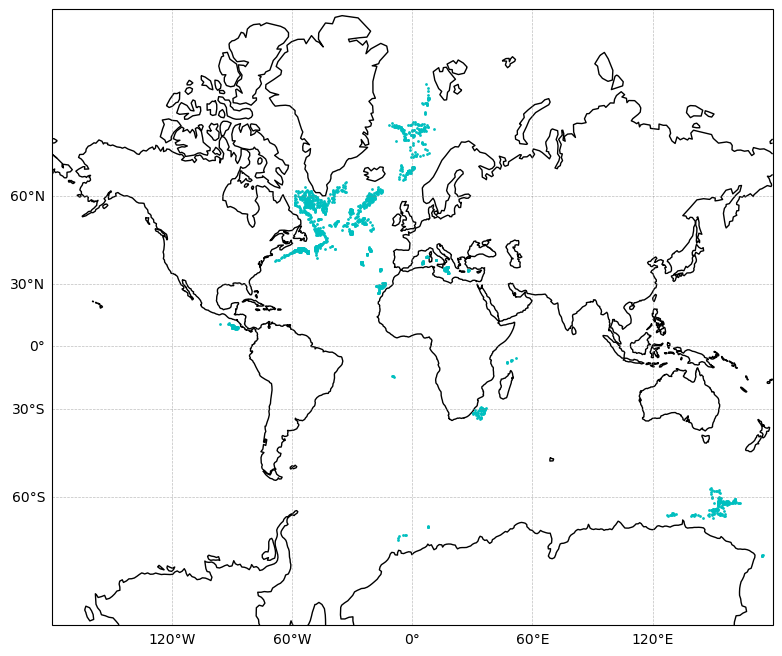

In [10]:
fig=plt.figure(figsize=(12,8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.coastlines()
ax.plot(groundings_arvor['lon'],groundings_arvor['lat'],'.c', markersize=4, markeredgecolor='None', alpha=1, transform=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
ax.set_global()

Text(0, 0.5, 'Gebco bathy [m]')

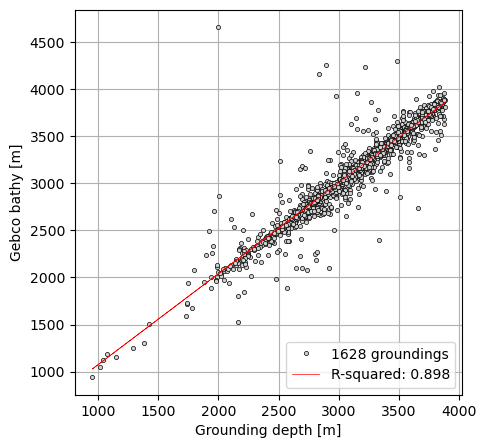

In [11]:
import scipy.stats as stats
x=groundings_arvor['grnd'].values
y=-1*groundings_arvor['gebco2'].values
res = stats.linregress(x, y)

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(x,y,'o',label=f"{len(x)} groundings", color='lightgrey', markersize=3, markeredgecolor='k', markeredgewidth=0.5)
plt.plot(x, res.intercept + res.slope*x, 'r',linewidth=0.5,label=f"R-squared: {res.rvalue**2:.3f}")
#ax.set_xlim([1000,5000])
#ax.set_ylim([1000,5000])
ax.legend()
ax.set_xlabel('Grounding depth [m]')
ax.set_ylabel('Gebco bathy [m]')
#fig.savefig('groundingVsBathy.png')